In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv(r"D:\practice files\Train  loan.csv")
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


# Literature Review: Loan Approval Prediction

| Paper Title / Source | Key Findings | | |
|---|---|---|---|
| Haque & Hassan (2024) | Credit history was the strongest factor for loan approval. Applicant income, co-applicant income, and loan amount also had major impact. |  |
| Singh et al. (2025) | Employment status and collateral strongly affected approval decisions and could introduce human bias. |
| Muhammad et al. (2024) | Loan amount was a major factor affecting approval risk. Higher loan requests showed higher risk patterns. | 

# Loan Approval Dataset — Deep Feature Understanding

## Dataset Goal

This dataset is used to predict:

> Whether a customer's loan should be approved or rejected.

Target column:
- `Loan_Status`

# 1. Loan_ID

## What it Means
Unique ID given to every loan application.

Example:
- LP001002
- LP001003

---

# 2. Gender

Values:
- Male
- Female


# 3. Married

Values:
- Yes
- No

# 4. Dependents

Number of people financially dependent on applicant.

# 5. Education
- Education level of applicant.

# 6. Self_Employed

Values:
- Yes
- No

Whether applicant runs own business/freelance work.


# 7. ApplicantIncome

Numeric feature.

Main applicant's monthly income.


# 8. CoapplicantIncome:
Income of second applicant.

# 9. LoanAmount:
Amount of loan requested by customer.

# 10. Loan_Amount_Term

Measured in months.

# 11. Credit_History:
Whether customer repaid previous loans properly.
> customer's financial reputation

# 12. Property_Area

Values:
- Urban
- Semiurban
- Rural
- Location category of applicant's property/home.

# 13. Loan_Status (Target Variable):
Whether loan was approved.

# Entire Dataset Purpose

The goal is to use all features to predict:

> Should this customer receive loan approval?

# Risk Estimation

Banks try to answer:

> "Can this customer repay loan safely?"

The dataset helps estimate:
- financial strength
- repayment reliability
- household stability
- customer trustworthiness


# Important Hidden Relationships

| Relationship | Why Important |
|---|---|
| Income vs LoanAmount | repayment burden |
| Credit_History vs Approval | customer trust |
| Dependents vs Income | financial pressure |
| Education vs Income | earning stability |
| CoapplicantIncome vs Approval | household support |
| Loan Term vs Risk | EMI affordability |

---

# Most Important Feature Groups

---

## Financial Features
These measure repayment ability:
- ApplicantIncome
- CoapplicantIncome
- LoanAmount

---

## Risk Features
These measure financial uncertainty:
- Credit_History
- Self_Employed

# HYPOTHESIS:
- bad credit history increase rejection.
- urban customers receive more approvals.
-  income stability affect approval.

In [4]:
print("--- Dataset Shape ---")
print(df.shape)

--- Dataset Shape ---
(614, 13)


In [9]:
df.sample(3)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
482,LP002537,Male,Yes,0,Graduate,No,2083,3150.0,128.0,360.0,1.0,Semiurban,Y
11,LP001027,Male,Yes,2,Graduate,NaN,2500,1840.0,109.0,360.0,1.0,Urban,Y
191,LP001656,Male,No,0,Graduate,No,12000,0.0,164.0,360.0,1.0,Semiurban,N


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [7]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [8]:
# there are missing values in some columns 

In [17]:
32/614*100

5.211726384364821

In [13]:
df['LoanAmount'].describe()

count    592.000000
mean     146.412162
std       85.587325
min        9.000000
25%      100.000000
50%      128.000000
75%      168.000000
max      700.000000
Name: LoanAmount, dtype: float64

In [ ]:
# rightly skewed loan amount feature.

In [14]:
df['Loan_Amount_Term'].describe()

count    600.00000
mean     342.00000
std       65.12041
min       12.00000
25%      360.00000
50%      360.00000
75%      360.00000
max      480.00000
Name: Loan_Amount_Term, dtype: float64

In [15]:
df['Credit_History'].describe()

count    564.000000
mean       0.842199
std        0.364878
min        0.000000
25%        1.000000
50%        1.000000
75%        1.000000
max        1.000000
Name: Credit_History, dtype: float64

In [16]:
df['Credit_History'].value_counts()

Credit_History
1.0    475
0.0     89
Name: count, dtype: int64

In [58]:
df['Credit_History'] = df['Credit_History'].map({1: 'Yes', 0: 'No'})

# imputing  appropriate values:

In [59]:
imputation_strategy = {
    'Gender': {'method': 'mode', 'reason': 'Low nulls, categorical'},
    'Married': {'method': 'mode', 'reason': 'Very few nulls'},
    'Dependents': {'method': 'mode', 'reason': 'Categorical, low nulls'},
    'Self_Employed': {'method': 'mode', 'reason': '<10% nulls'},
    'LoanAmount': {'method': 'median', 'reason': 'Numerical, skewed data'},
    'Loan_Amount_Term': {'method': 'mode', 'reason': 'Likely 360 months'},
    'Credit_History': {'method': 'mode OR create unknown flag', 'reason': 'High-impact feature, 8% nulls'}
}

for col, strategy in imputation_strategy.items():
    print(f"{col:20} → {strategy['method']:20} | {strategy['reason']}")

Gender               → mode                 | Low nulls, categorical
Married              → mode                 | Very few nulls
Dependents           → mode                 | Categorical, low nulls
Self_Employed        → mode                 | <10% nulls
LoanAmount           → median               | Numerical, skewed data
Loan_Amount_Term     → mode                 | Likely 360 months
Credit_History       → mode OR create unknown flag | High-impact feature, 8% nulls


In [60]:
categorical_cols = ['Gender', 'Married', 'Dependents', 'Self_Employed', 'Loan_Amount_Term']

for col in categorical_cols:
    mode_value = df[col].mode()[0]  # Most frequent value
    df[col].fillna(mode_value, inplace=True)
    print(f"Filled {col} with mode: {mode_value}")

Filled Gender with mode: Male
Filled Married with mode: Yes
Filled Dependents with mode: 0
Filled Self_Employed with mode: No
Filled Loan_Amount_Term with mode: 360.0


C:\Users\Asus\AppData\Local\Temp\ipykernel_29848\139647335.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(mode_value, inplace=True)


In [61]:
df['Loan_Amount_Term'].value_counts()

Loan_Amount_Term
360.0    526
180.0     44
480.0     15
300.0     13
240.0      4
84.0       4
120.0      3
60.0       2
36.0       2
12.0       1
Name: count, dtype: int64

In [62]:
median_loan = df['LoanAmount'].median()
df['LoanAmount'].fillna(median_loan, inplace=True)
print(f"Filled LoanAmount with median: {median_loan}")

Filled LoanAmount with median: 128.0


C:\Users\Asus\AppData\Local\Temp\ipykernel_29848\1446725215.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['LoanAmount'].fillna(median_loan, inplace=True)


In [63]:
df['Credit_History_Missing'] = df['Credit_History'].isnull().astype(int)     # you get 1 where data is missing, 0 otherwise in new column 

In [64]:
df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace=True)

C:\Users\Asus\AppData\Local\Temp\ipykernel_29848\1608471621.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace=True)


In [65]:
print(" Done! Nulls remaining:", df['Credit_History'].isnull().sum())
print("Value counts:", df['Credit_History'].value_counts().to_dict())

 Done! Nulls remaining: 0
Value counts: {'Yes': 525, 'No': 89}


In [66]:
df.isnull().sum()

Loan_ID                   0
Gender                    0
Married                   0
Dependents                0
Education                 0
Self_Employed             0
ApplicantIncome           0
CoapplicantIncome         0
LoanAmount                0
Loan_Amount_Term          0
Credit_History            0
Property_Area             0
Loan_Status               0
Credit_History_Missing    0
Total_Income              0
Income_to_Loan            0
dtype: int64

In [67]:
df.sample(2)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Credit_History_Missing,Total_Income,Income_to_Loan
322,LP002054,Male,Yes,2,Not Graduate,No,3601,1590.0,128.0,360.0,Yes,Rural,Y,0,5191.0,40.554688
206,LP001693,Female,No,0,Graduate,No,3244,0.0,80.0,360.0,Yes,Urban,Y,0,3244.0,40.550000


# feature engineering

**Total_income**

In [68]:
df['Total_Income'] = (
    df['ApplicantIncome'] +
    df['CoapplicantIncome']
)

In [69]:
df['Income_to_Loan'] = (
    df['Total_Income'] /
    df['LoanAmount']
)
# This ratio shows how much income the borrower has for each unit of loan. A higher ratio means the borrower can more easily repay the loan.

In [128]:
df.sample(3)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Credit_History_Missing,Total_Income,Income_to_Loan,Loan_Status_Numeric,Loan_Status_Binary
428,LP002369,Male,Yes,0,Graduate,No,2920,16.120001,87.0,360.0,Yes,Rural,Y,0,2936.120001,33.748506,1,1
62,LP001207,Male,Yes,0,Not Graduate,Yes,2609,3449.000000,165.0,180.0,No,Rural,N,0,6058.000000,36.715152,0,0
603,LP002958,Male,No,0,Graduate,No,3676,4301.000000,172.0,360.0,Yes,Rural,Y,0,7977.000000,46.377907,1,1


# UNIVARIATE ANALYSIS

C:\Users\Asus\AppData\Local\Temp\ipykernel_29848\492737671.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


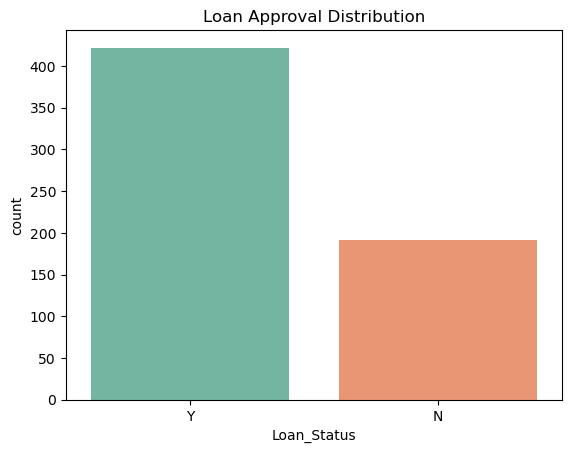

In [70]:
sns.countplot(
    data=df,
    x='Loan_Status',
    palette='Set2'
)

plt.title('Loan Approval Distribution')

plt.show()

- Approvals dominate the dataset, indicating relatively lenient lending behavior.
- Rejections form the true risk segment and are analytically more valuable.
- Dataset imbalance may bias predictive models toward approvals.

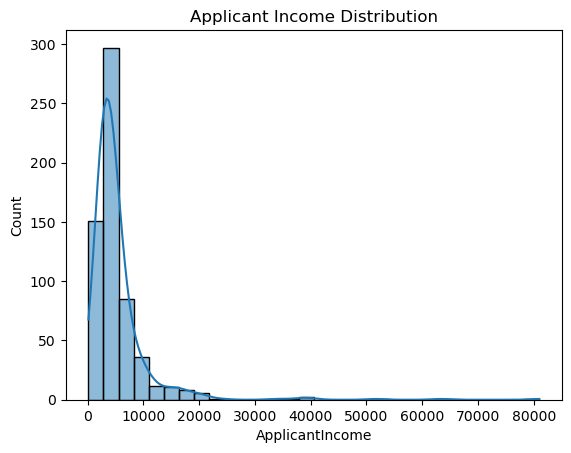

In [71]:
sns.histplot(
    df['ApplicantIncome'],
    kde=True,
    bins=30
)

plt.title('Applicant Income Distribution')

plt.show()

- Income is heavily right-skewed, with few extremely high earners.
- Most borrowers belong to middle-income groups.
- With many income sources, total income alone doesn't show if you can afford the loan — you need to check what's left after bills.

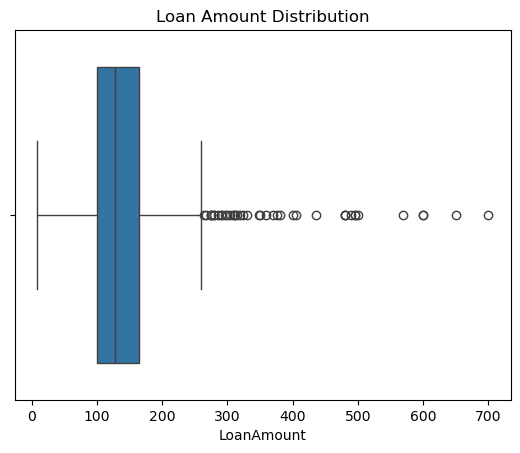

In [72]:
sns.boxplot(
    x=df['LoanAmount']
)

plt.title('Loan Amount Distribution')

plt.show()

- Most applicants request moderate loan amounts.
- Extreme loan outliers represent high financial exposure for the lender.(Very large or unusual loans carry more risk. If one such loan defaults, the lender loses a lot of money — much more than with a typical small loan.)
- A smaller loan that gets repaid fully is better for the lender than a huge loan that might default.

C:\Users\Asus\AppData\Local\Temp\ipykernel_29848\1871191833.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


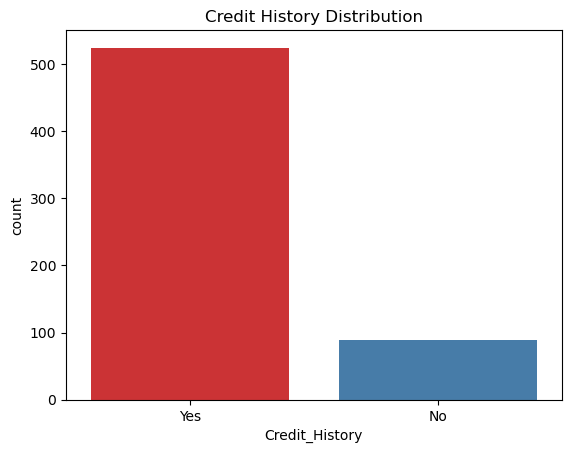

In [73]:
sns.countplot(
    data=df,
    x='Credit_History',
    palette='Set1'
)

plt.title('Credit History Distribution')

plt.show()

- Most applicants possess good repayment history(1).
- Creditworthiness acts as an initial trust filter in lending.
- Poor credit history applicants form the concentrated high-risk group.

C:\Users\Asus\AppData\Local\Temp\ipykernel_29848\2295023415.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


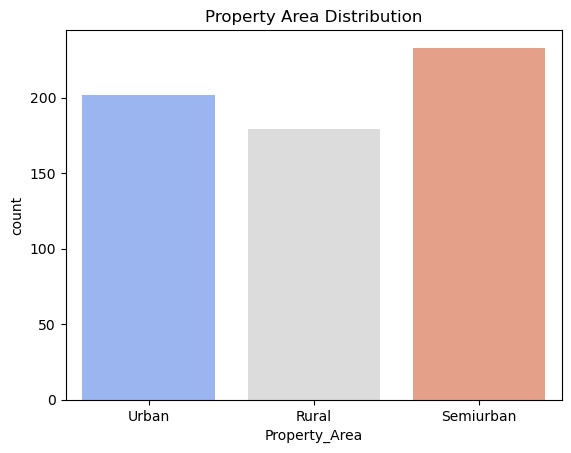

In [75]:
sns.countplot(
    data=df,
    x='Property_Area',
    palette='coolwarm'
)

plt.title('Property Area Distribution')

plt.show()

- Semiurban applicants dominate the dataset.
- Lending activity appears strongest in economically growing regions.
- Geographic location may indirectly reflect repayment stability.

C:\Users\Asus\AppData\Local\Temp\ipykernel_29848\4278530895.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


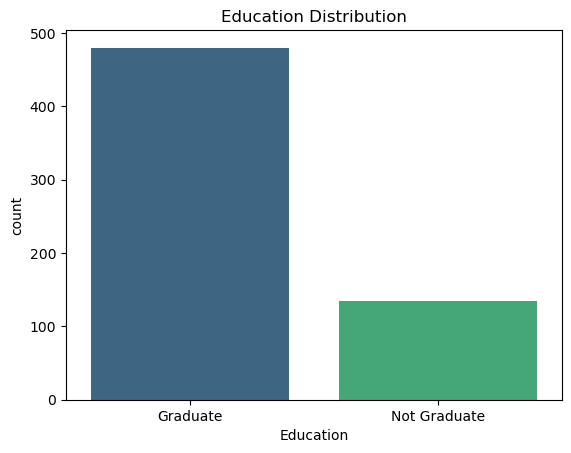

In [76]:
sns.countplot(
    data=df,
    x='Education',
    palette='viridis'
)

plt.title('Education Distribution')

plt.show()

- Graduated applicants form the majority borrower segment.
- Education likely correlates with financial stability and employability.

C:\Users\Asus\AppData\Local\Temp\ipykernel_29848\3496061446.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


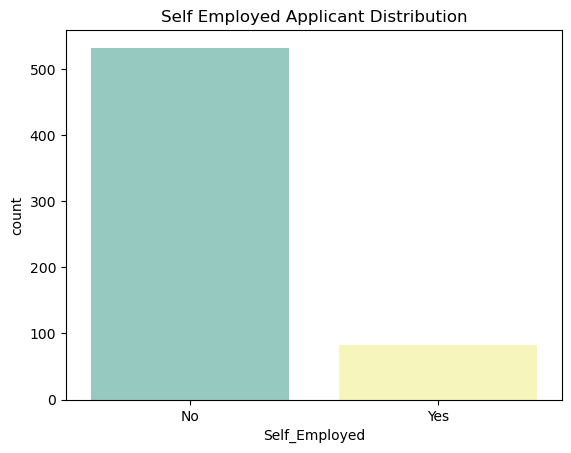

In [78]:
sns.countplot(
    data=df,
    x='Self_Employed',
    palette='Set3'
)

plt.title('Self Employed Applicant Distribution')

plt.show()

- Salaried applicants dominate the dataset.
- Stable income structures are preferred in traditional lending.
- Self-employed applicants may face stricter repayment scrutiny.

C:\Users\Asus\AppData\Local\Temp\ipykernel_29848\1308405402.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


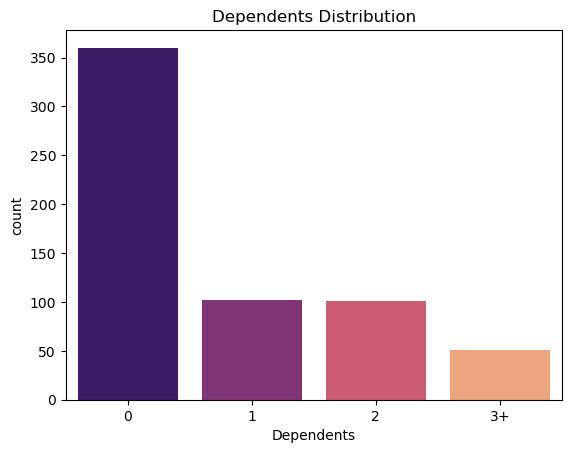

In [79]:
sns.countplot(
    data=df,
    x='Dependents',
    palette='magma'
)

plt.title('Dependents Distribution')

plt.show()

- most applicants have low household dependency burden.
- Higher dependents may reduce repayment flexibility.
- Family financial pressure indirectly affects lending risk.(job loss,medical emergency)

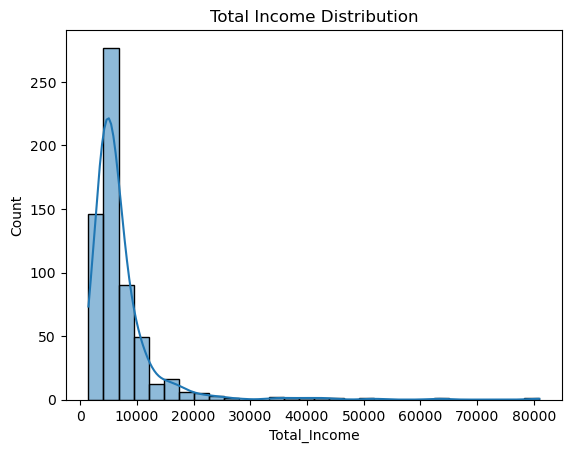

In [82]:
sns.histplot(
    df['Total_Income'],
    kde=True,
    bins=30
)

plt.title('Total Income Distribution')

plt.show()

- Income Inequality is High.
- More Income = Easier Loan Repayment.
- Dual-income households improve repayment confidence.

# BIVARIATE analysis

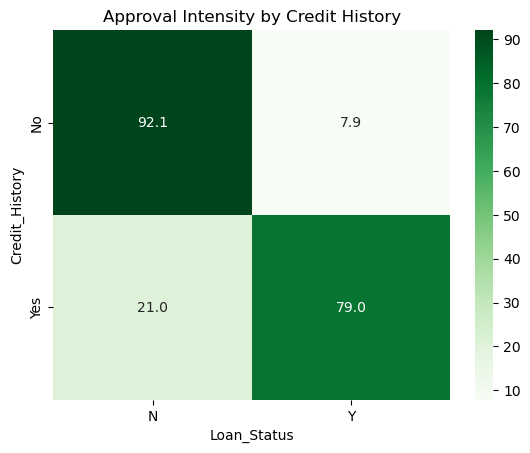

In [87]:
credit_heat = (
    pd.crosstab(
        df['Credit_History'],
        df['Loan_Status'],
        normalize='index'
    ) * 100
)

sns.heatmap(
    credit_heat,
    annot=True,
    fmt='.1f',
    cmap='Greens'
)

plt.title(
    'Approval Intensity by Credit History'
)

plt.show()

- Credit history is the strongest approval driver in the dataset.
- Applicants with good repayment records receive significantly more approvals.
- Banks prioritize repayment trustworthiness over aggressive loan expansion.

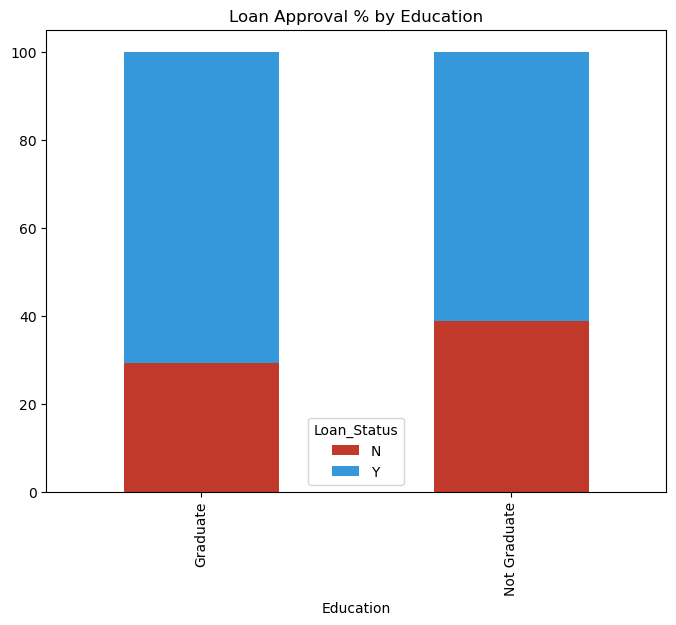

In [89]:
education_loan = (
    pd.crosstab(
        df['Education'],
        df['Loan_Status'],
        normalize='index'
    ) * 100
)

education_loan.plot(
    kind='bar',
    stacked=True,
    figsize=(8,6),
    color=['#c0392b', '#3498db']
)

plt.title('Loan Approval % by Education')

plt.show()

- Graduated applicants show stronger approval performance.
- Education likely reflects employment and income stability.
- Educational advantage is secondary to repayment behavior.

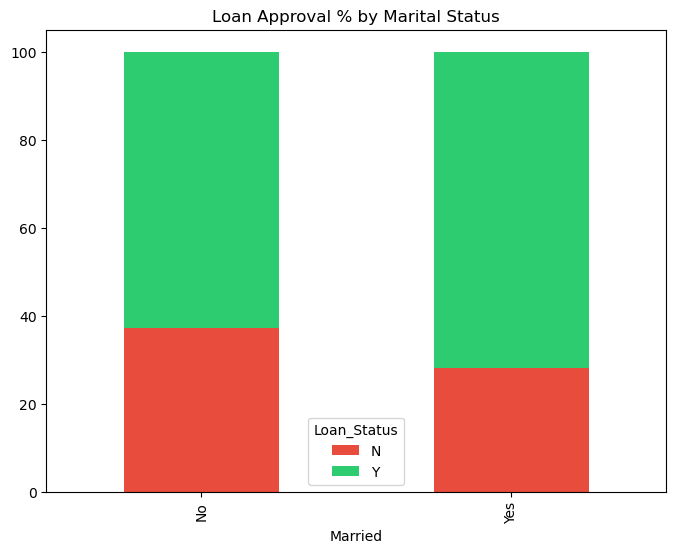

In [90]:
married_loan = (
    pd.crosstab(
        df['Married'],
        df['Loan_Status'],
        normalize='index'
    ) * 100
)

married_loan.plot(
    kind='bar',
    stacked=True,
    figsize=(8,6),
    color=['#e74c3c', '#2ecc71']
)

plt.title('Loan Approval % by Marital Status')

plt.show()

- Married applicants receive approvals more frequently.
- Household stability improves repayment confidence.
- Demographic stability influences financial trust perception.

C:\Users\Asus\AppData\Local\Temp\ipykernel_29848\1294053182.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




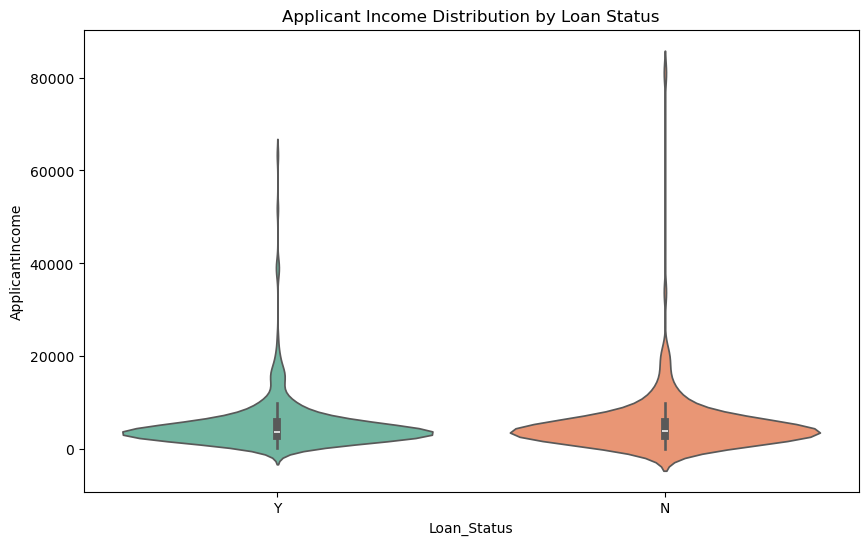

In [94]:
plt.figure(figsize=(10,6))

sns.violinplot(
    data=df,
    x='Loan_Status',
    y='ApplicantIncome',
    palette='Set2'
)

plt.title(
    'Applicant Income Distribution by Loan Status'
)

plt.show()

- The income distribution of approved and rejected applicants is very similar.
- Income alone does not strongly determine loan approval/rejection in this dataset.
- The bulk of applicants (both approved and rejected) have incomes below ₹20,000.
- Since income distributions overlap, credit history, dependents likely play a bigger role in loan approvals.

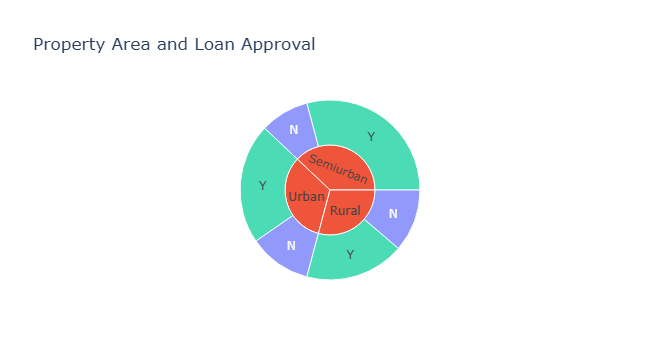

In [115]:
fig = px.sunburst(
    df,

    path=[
        'Property_Area',
        'Loan_Status'
    ],

    color='Loan_Status',

    title='Property Area and Loan Approval'
)

fig.show()

- Semiurban applicants dominate approval segments.
- Rural regions show relatively stronger rejection proportion.
- Geographic location indirectly affects lending confidence.

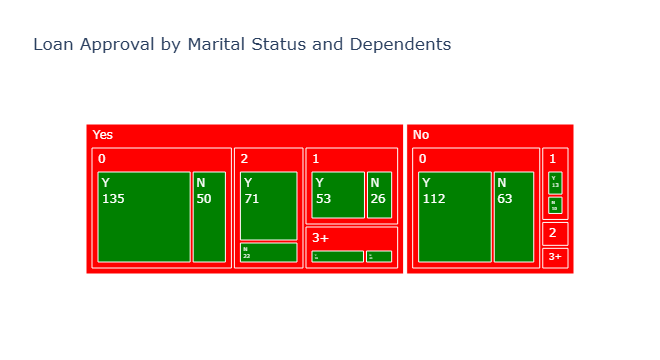

In [126]:
import plotly.express as px

fig = px.treemap(
    df,
    path=['Married', 'Dependents', 'Loan_Status'],  
    color='Loan_Status',  
    color_discrete_sequence=['green', 'red'], 
    title='Loan Approval by Marital Status and Dependents'
)

fig.update_traces(textinfo="label+value")  # Show labels and counts
fig.show()

- Married applicants with fewer dependents dominate the dataset.
- High dependency burden may reduce repayment flexibility.
- Married + 0 Dependents = Best chance of approval.
- Unmarried + 0 Dependents = Still good, but slightly less than married.
- More dependents = More rejections (especially if unmarried).
- 3+ Dependents = Very hard to get approved, regardless of marital status.

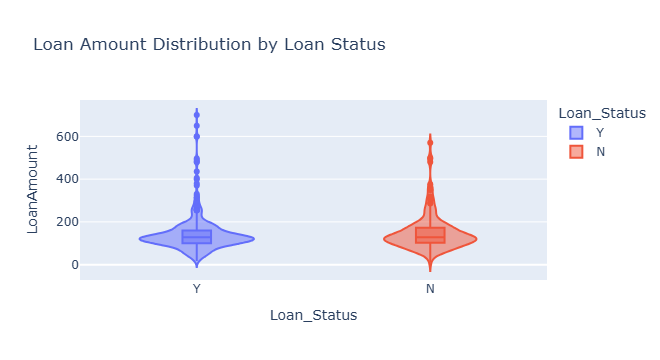

In [117]:
fig = px.violin(
    df,

    x='Loan_Status',
    y='LoanAmount',

    color='Loan_Status',

    box=True,

    title='Loan Amount Distribution by Loan Status'
)

fig.show()

- Rejected applicants show relatively riskier loan ranges.
- Approved loans concentrate around moderate borrowing levels.
- Large loan amounts require stronger repayment confidence.

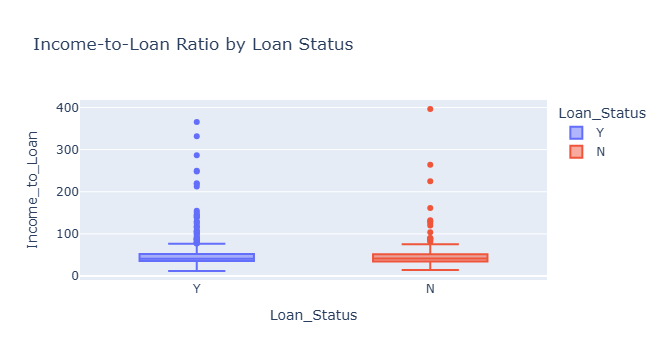

In [118]:
df['Income_to_Loan'] = (
    df['Total_Income'] /
    df['LoanAmount']
)

fig = px.box(
    df,

    x='Loan_Status',
    y='Income_to_Loan',

    color='Loan_Status',

    title='Income-to-Loan Ratio by Loan Status'
)                 #This ratio shows how much income the borrower has for each unit of loan.

fig.show()     # A higher ratio means the borrower can more easily repay the loan.

- Higher income-to-loan ratio = More approvals, it signals strong repayment capacity.
- Lower ratio = More rejections.
- Even high ratios can get rejected if other risks exist (e.g., bad credit).

# MULTIVARIATE ANALYSIS

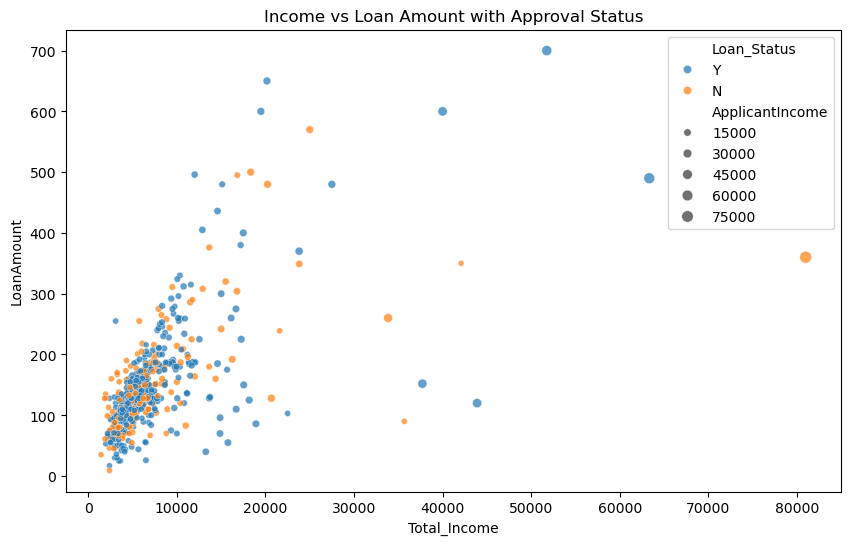

In [104]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='Total_Income',
    y='LoanAmount',
    size='ApplicantIncome',
    hue='Loan_Status',
    alpha=0.7
)

plt.title(
    'Income vs Loan Amount with Approval Status'
)

plt.show()

- Higher Income + Smaller Loan = More Approvals.
- Banks approve loans when income is much higher than the loan amount (easier to repay).
- Many orange dots (N) appear where income is low (e.g., below ₹20,000) and loan amounts are large (e.g., ₹300–₹500). If the loan is too big compared to income, banks see higher repayment risk.
- **Outliers Show Extremes**
- Some approved loans (Y) have very high loan amounts (₹600–₹700) but also high incomes (₹50,000–₹80,000).
- Some rejected loans (N) have low incomes but small loan amounts, suggesting other factors (like credit history) may have caused rejection.



C:\Users\Asus\AppData\Local\Temp\ipykernel_29848\3900795005.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




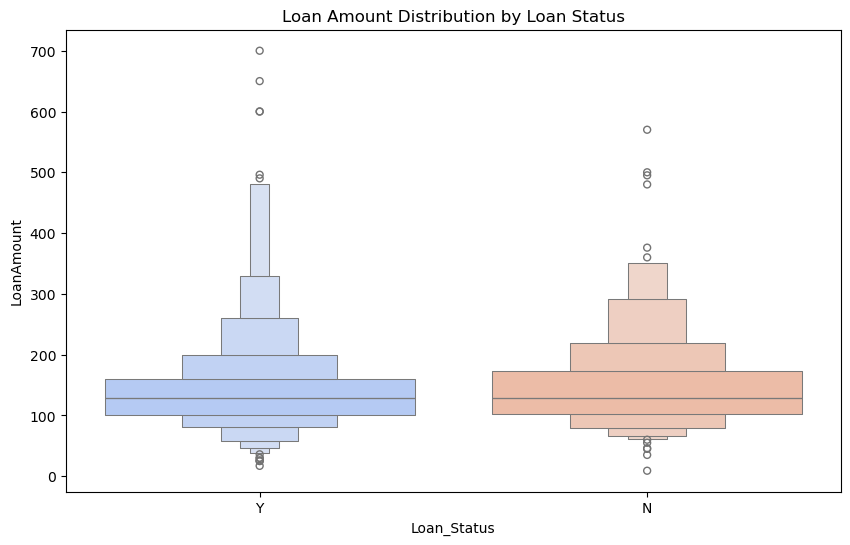

In [109]:
plt.figure(figsize=(10,6))

sns.boxenplot(
    data=df,
    x='Loan_Status',
    y='LoanAmount',
    palette='coolwarm'
)

plt.title(
    'Loan Amount Distribution by Loan Status'
)

plt.show()

- Approved Loans (Y) Have Higher Amounts,(upto 700+),bank trust them with larger loans.
- Rejected applicants (N) mostly ask for ₹100–₹400, but some even apply for ₹500+ and get rejected.
- Most Loans Are Around ₹100–₹200
- Bigger loans → More approvals (but not always).
- Rejections happen even for big loans if risk is high.

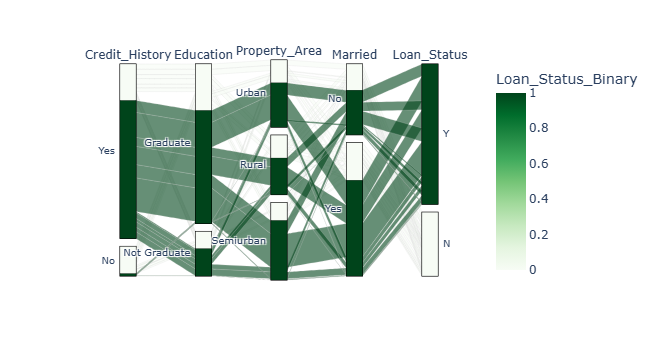

In [119]:
df['Loan_Status_Binary'] = (
    df['Loan_Status']
    .map({'N':0,'Y':1})
)

fig = px.parallel_categories(
    df,

    dimensions=[
        'Credit_History',
        'Education',
        'Property_Area',
        'Married',
        'Loan_Status'
    ],

    color='Loan_Status_Binary',

    color_continuous_scale=
    px.colors.sequential.Greens
)

fig.show()

- Strong credit history consistently drives approval flows.
- The chart reveals complete approval pathways visually
- Credit_History = Yes → Graduate → Urban → Married → Loan_Status = Y
- Semiurban + Graduate = High Approval

- Urban + Good Credit = Almost Guaranteed Approval

>If you live in a city and have good credit history, your loan will likely be approved.


- Rural + Not Graduate = More Rejections

>Non-graduates from rural areas face more loan rejections.


- Married + Urban + Good Credit = Strongest Approval Cluster

> Married people in cities with good credit history have the highest chance of loan approval.


- Semiurban + Not Graduate = Mixed Results

>Non-graduates in semiurban areas have a 50-50 chance—some get approved, some don’t.



# Executive Summary

The exploratory analysis reveals that loan approval decisions are primarily driven by:

- repayment trustworthiness
- affordability balance
- financial stability
- household repayment capacity

>Among all variables, **credit history**emerges as the strongest predictor of loan approval.

***Applicants with***:

- strong repayment history,
- moderate loan burden,
- balanced income structure,

>show the highest approval probability.

**Advanced visual analysis further reveals that**:

- affordability matters more than raw income,
- household burden influences repayment confidence,
- and financial proportionality dominates lending decisions.
# Key Business Findings: "Strongest Approval Indicators"
- Good credit history
- Balanced income-to-loan ratio
- Moderate loan burden
- Stable household structure
- Strong total household income

**Strongest Rejection Indicators:**
- Poor repayment history
- Large repayment burden
- High household dependency pressure
  
# Final Conclusion

The dataset demonstrates that modern lending systems fundamentally prioritize:

- repayment sustainability
over
- aggressive lending expansion.
>Banks prefer safe loans (where borrowers can repay) over risking defaults by lending too much.

**The most meaningful insights emerge from:**

- categorical interaction analysis,
- affordability segmentation,
- behavioral trust patterns,
- and multivariate financial relationships